# TCGA Clinical Genomics Data Analysis - Colorectal cancers

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
#read in data
tcga_data = pd.read_csv('coadread_tcga_pan_can_atlas_2018_clinical_data.txt', sep='\t')
print(tcga_data.shape)
tcga_data.head()

(594, 63)


,Study ID,Patient ID,Sample ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Aneuploidy Score,Buffa Hypoxia Score,Cancer Type,TCGA PanCanAtlas Cancer Type Acronym,...,Tumor Break Load,Tissue Prospective Collection Indicator,Tissue Retrospective Collection Indicator,Tissue Source Site,Tissue Source Site Code,TMB (nonsynonymous),Tumor Disease Anatomic Site,Tumor Type,Patient Weight,Winter Hypoxia Score
0,coadread_tcga_pan_can_atlas_2018,TCGA-3L-AA1B,TCGA-3L-AA1B-01,61.0,STAGE I,7TH,19.0,5.0,Colorectal Cancer,COAD,...,19.0,Yes,No,Indivumed,3L,4.033333,Colon,Colon Adenocarcinoma,63.300,-12.0
1,coadread_tcga_pan_can_atlas_2018,TCGA-4N-A93T,TCGA-4N-A93T-01,67.0,STAGE IIIB,7TH,13.0,-15.0,Colorectal Cancer,COAD,...,30.0,Yes,No,Indivumed,4N,2.900000,Colon,Colon Adenocarcinoma,134.000,-6.0
2,coadread_tcga_pan_can_atlas_2018,TCGA-4T-AA8H,TCGA-4T-AA8H-01,42.0,STAGE IIA,7TH,18.0,15.0,Colorectal Cancer,COAD,...,14.0,No,Yes,Indivumed,4T,4.000000,Colon,"Colon Adenocarcinoma, Mucinous Type",107.956,-4.0
3,coadread_tcga_pan_can_atlas_2018,TCGA-5M-AAT4,TCGA-5M-AAT4-01,74.0,STAGE IV,6TH,18.0,35.0,Colorectal Cancer,COAD,...,82.0,No,Yes,Indivumed,5M,5.833333,Colon,Colon Adenocarcinoma,NaN,32.0
4,coadread_tcga_pan_can_atlas_2018,TCGA-5M-AAT5,TCGA-5M-AAT5-01,NaN,NaN,NaN,10.0,33.0,Colorectal Cancer,COAD,...,27.0,NaN,NaN,Molecular Response,5M,2.633333,NaN,Colon Adenocarcinoma,NaN,18.0


In [17]:
#exploration 
print(tcga_data.shape)
for col in tcga_data.columns:
    print(col)
    print(tcga_data[col].isna().sum())




(594, 63)
Study ID
0
Patient ID
0
Sample ID
0
Diagnosis Age
2
Neoplasm Disease Stage American Joint Committee on Cancer Code
14
American Joint Committee on Cancer Publication Version Type
70
Aneuploidy Score
8
Buffa Hypoxia Score
229
Cancer Type
0
TCGA PanCanAtlas Cancer Type Acronym
0
Cancer Type Detailed
0
Last Communication Contact from Initial Pathologic Diagnosis Date
50
Birth from Initial Pathologic Diagnosis Date
4
Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value
2
Disease Free (Months)
371
Disease Free Status
371
Months of disease-specific survival
4
Disease-specific Survival status
24
Ethnicity Category
246
Form completion date
2
Fraction Genome Altered
11
Genetic Ancestry Label
7
Neoplasm Histologic Grade
594
Neoadjuvant Therapy Type Administered Prior To Resection Text
2
ICD-10 Classification
3
International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code
3
International Classification of Diseases for Oncology, Third Editio

In [18]:
#drop cols with alot of missing data and those that don't seem relevant
cols_drop = ["Disease Free (Months)", "Disease Free Status", "Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value", "Last Communication Contact from Initial Pathologic Diagnosis Date",
    "Study ID", "Patient ID", "Sample ID", "Other Patient ID", "Tissue Source Site", "Tissue Source Site Code", "TCGA PanCanAtlas Cancer Type Acronym", "Oncotree Code", "ICD-10 Classification", "International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code",
    "International Classification of Diseases for Oncology, Third Edition ICD-O-3 Site Code", "Birth from Initial Pathologic Diagnosis Date", "Form completion date", "Informed consent verified",
    "In PanCan Pathway Analysis", "Number of Samples Per Patient", "Somatic Status", "Tissue Prospective Collection Indicator", "Tissue Retrospective Collection Indicator", "Sample Type", "Tumor Type",
    "Primary Lymph Node Presentation Assessment", 'Ragnum Hypoxia Score', 'Buffa Hypoxia Score', 'Winter Hypoxia Score', 'Neoplasm Histologic Grade']
tcga_data = tcga_data.drop(columns=cols_drop)
print(tcga_data.shape)

(594, 33)


In [19]:
print(tcga_data.isna().sum())
tcga_data.head()


Diagnosis Age                                                                  2
Neoplasm Disease Stage American Joint Committee on Cancer Code                14
American Joint Committee on Cancer Publication Version Type                   70
Aneuploidy Score                                                               8
Cancer Type                                                                    0
Cancer Type Detailed                                                           0
Months of disease-specific survival                                            4
Disease-specific Survival status                                              24
Ethnicity Category                                                           246
Fraction Genome Altered                                                       11
Genetic Ancestry Label                                                         7
Neoadjuvant Therapy Type Administered Prior To Resection Text                  2
MSI MANTIS Score            

,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Aneuploidy Score,Cancer Type,Cancer Type Detailed,Months of disease-specific survival,Disease-specific Survival status,Ethnicity Category,Fraction Genome Altered,...,Progression Free Status,Prior Diagnosis,Race Category,Radiation Therapy,Sex,Subtype,Tumor Break Load,TMB (nonsynonymous),Tumor Disease Anatomic Site,Patient Weight
0,61.0,STAGE I,7TH,19.0,Colorectal Cancer,Colon Adenocarcinoma,15.616267,0:ALIVE OR DEAD TUMOR FREE,Not Hispanic Or Latino,0.1127,...,0:CENSORED,No,Black or African American,No,Female,COAD_CIN,19.0,4.033333,Colon,63.300
1,67.0,STAGE IIIB,7TH,13.0,Colorectal Cancer,Colon Adenocarcinoma,4.799947,0:ALIVE OR DEAD TUMOR FREE,Not Hispanic Or Latino,0.3130,...,0:CENSORED,No,Black or African American,No,Male,COAD_CIN,30.0,2.900000,Colon,134.000
2,42.0,STAGE IIA,7TH,18.0,Colorectal Cancer,Mucinous Adenocarcinoma of the Colon and Rectum,12.657396,0:ALIVE OR DEAD TUMOR FREE,Not Hispanic Or Latino,0.2816,...,0:CENSORED,No,Black or African American,No,Female,COAD_CIN,14.0,4.000000,Colon,107.956
3,74.0,STAGE IV,6TH,18.0,Colorectal Cancer,Colon Adenocarcinoma,1.610941,1:DEAD WITH TUMOR,Hispanic Or Latino,0.4095,...,1:PROGRESSION,No,Black or African American,No,Male,COAD_CIN,82.0,5.833333,Colon,NaN
4,NaN,NaN,NaN,10.0,Colorectal Cancer,Colon Adenocarcinoma,NaN,NaN,NaN,0.3435,...,NaN,NaN,NaN,NaN,NaN,COAD_CIN,27.0,2.633333,NaN,NaN


Great, this leaves a solid selection of possible outcome options, biological features, and treatment features. Not much patient demographic or exposure data, though. 
   
     
One feature that could be interesting is that of Aneuploidy, the gain or loss of whole chromosomes (https://pmc.ncbi.nlm.nih.gov/articles/PMC4714037/). 

The abstract of "Context is everything: aneuploidy in cancer", Ben-David et al, (https://www.nature.com/articles/s41576-019-0171-x), discusses some of the complexity in occurence of aneuploidy in cancer:     
*Cancer is driven by multiple types of genetic alterations, which range in size from point mutations to whole-chromosome gains and losses, known as aneuploidy. Chromosome instability, the process that gives rise to aneuploidy, can promote tumorigenesis by increasing genetic heterogeneity and promoting tumour evolution. However, much less is known about how aneuploidy itself contributes to tumour formation and progression. Unlike some pan-cancer oncogenes and tumour suppressor genes that drive transformation in virtually all cell types and cellular contexts, aneuploidy is not a universal promoter of tumorigenesis. Instead, recent studies suggest that aneuploidy is a context-dependent, cancer-type-specific oncogenic event that may have clinical relevance as a prognostic marker and as a potential therapeutic target.*

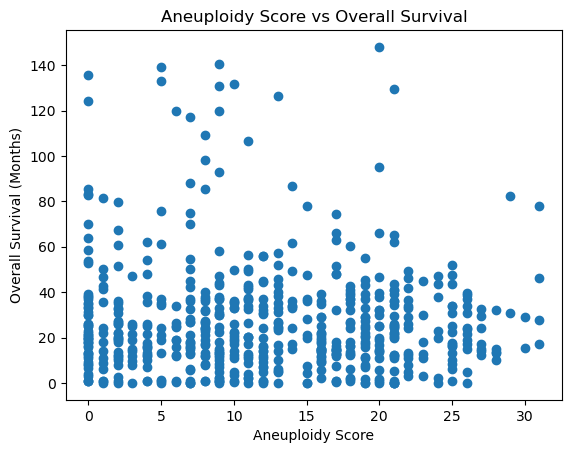

In [ ]:
#visualizations
#aneuploidy vs overall survival
plt.scatter(tcga_data['Aneuploidy Score'], tcga_data['Overall Survival (Months)'])
plt.xlabel('Aneuploidy Score')
plt.ylabel('Overall Survival (Months)')
plt.title('Aneuploidy Score vs Overall Survival')
plt.show()


This plot looks pretty garbagey. The literature indicates that "Kaplan Meier Curves" are commonly used for survival data, so that may be interesting to look into.  
https://pmc.ncbi.nlm.nih.gov/articles/PMC3932959/

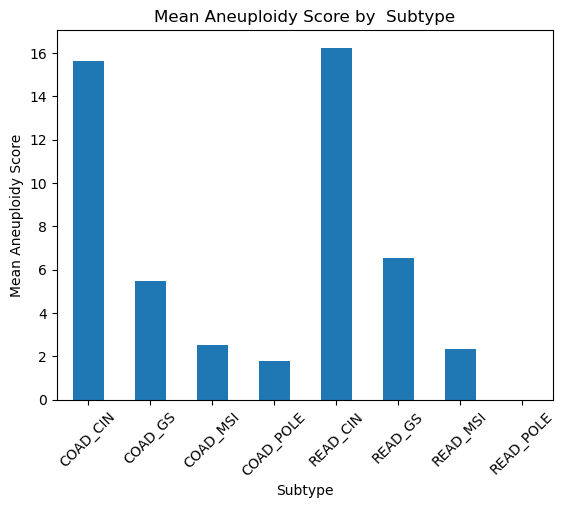

In [24]:
#mean aneuploidy score per subtype
subtype_means = tcga_data.groupby('Subtype')['Aneuploidy Score'].mean()
subtype_means.plot(kind='bar')
plt.xlabel('Subtype')
plt.ylabel('Mean Aneuploidy Score')
plt.title('Mean Aneuploidy Score by  Subtype')
plt.xticks(rotation=45)
plt.show()


Looking up the subtype codes, CIN = chromosomal instability, GS indicates genomic stability, and MSI = microsatellite instability. Microsatellites are short repeating sequences of DNA. 

https://www.mdanderson.org/cancerwise/what-is-microsatellite-instability-MSI.h00-159617067.html


Looks like there exists an R package specifically for dealing with this data, so that might be worth trying moving forward. 
https://bioconductor.org/packages/release/bioc/html/TCGAbiolinks.html

In [36]:
#write out the cleaned data
tcga_data.to_csv('coadread_tcga_pan_can_atlas_2018_clinical_data_cleaned.csv', index=False)